 Import dan Koneksi

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
import seaborn as sns 
from sqlalchemy import create_engine 
from dotenv import load_dotenv 
import os 
import warnings 
warnings.filterwarnings('ignore') 
  
# Load env variables 
load_dotenv() 
  
# Koneksi ke PostgreSQL 
engine = create_engine( 
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}" 
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}" 
) 
  
# Load clean data 
df = pd.read_sql('SELECT * FROM clean_orders_master', engine) 
print(f'Data loaded: {df.shape[0]:,} rows x {df.shape[1]} columns') 
  
# Setup style 
sns.set_theme(style='whitegrid', palette='Set2') 
plt.rcParams.update({'figure.figsize': (13, 6), 'font.family': 'sans-serif'}) 
os.makedirs('../output/figures', exist_ok=True) 
print('Setup complete!') 

Data loaded: 112,769 rows x 27 columns
Setup complete!


Overview dan Info Data 

In [3]:
print('='*55) 
print('DATASET OVERVIEW') 
print('='*55) 
print(f'Total rows          : {len(df):,}') 
print(f'Total columns       : {df.shape[1]}') 
print(f'Unique orders       : {df["order_id"].nunique():,}') 
print(f'Unique customers    : {df["customer_id"].nunique():,}') 
print(f'Unique products     : {df["product_id"].nunique():,}') 
print(f'Date range          : {df["order_date"].min()} → {df["order_date"].max()}') 
print(f'Total revenue (est) : R$ {df["total_item_value"].sum():,.2f}') 
print() 
print('COLUMN TYPES:') 
print(df.dtypes) 
print() 
print('MISSING VALUES:') 
missing = df.isnull().sum() 
print(missing[missing > 0])

DATASET OVERVIEW
Total rows          : 112,769
Total columns       : 27
Unique orders       : 98,207
Unique customers    : 98,207
Unique products     : 32,729
Date range          : 2016-09-04 21:15:19 → 2018-09-03 09:06:57
Total revenue (est) : R$ 15,807,195.58

COLUMN TYPES:
order_id                         str
customer_id                      str
customer_unique_id               str
customer_city                    str
customer_state                   str
order_status                     str
order_date            datetime64[us]
order_month           datetime64[us]
order_year                   float64
order_month_num              float64
year_month                       str
product_id                       str
product_category                 str
item_sequence                float64
item_price                   float64
freight_value                float64
total_item_value             float64
payment_type                     str
payment_value                float64
installments        

Revenue Trend Bulanan

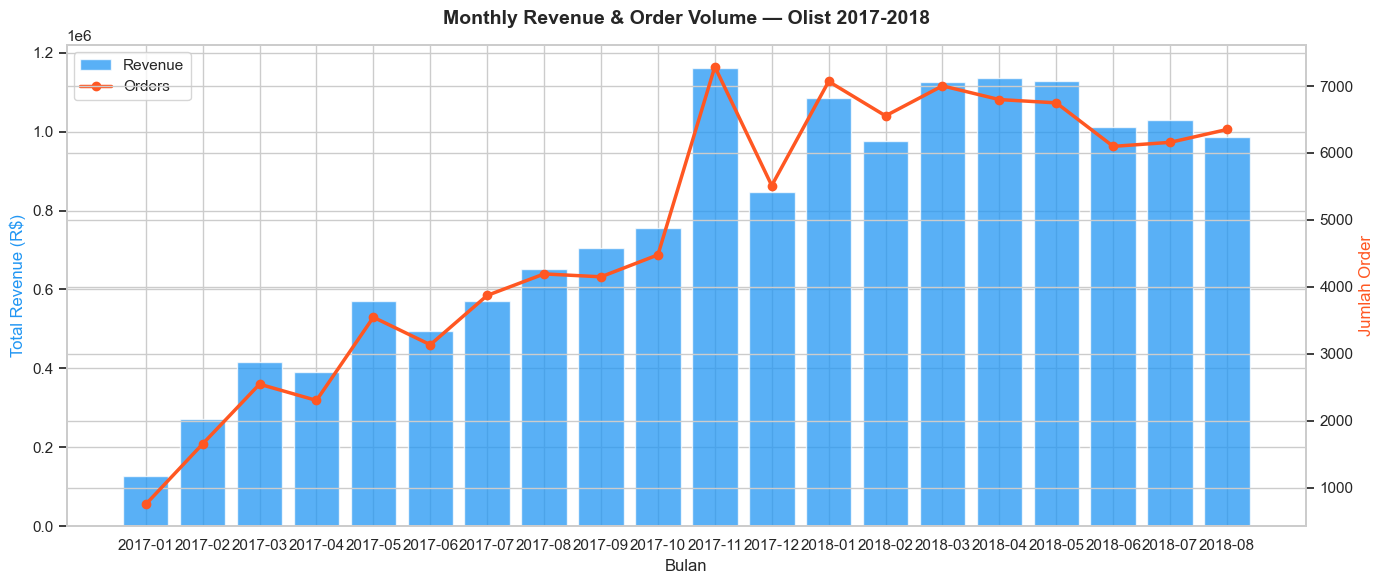

Insight: Revenue tumbuh konsisten dari Q1-2017 hingga peak di Nov-2017 (Black Friday Brazil)


In [5]:
df['order_date'] = pd.to_datetime(df['order_date']) 
df_delivered = df[df['order_status'] == 'delivered'].copy() 
  
monthly = ( 
    df_delivered 
    .groupby('year_month') 
    .agg( 
        total_revenue=('total_item_value', 'sum'), 
        total_orders=('order_id', 'nunique') 
    ) 
    .reset_index() 
) 
# Filter hanya 2017-01 sampai 2018-08 
monthly = monthly[ 
    (monthly['year_month'] >= '2017-01') & 
    (monthly['year_month'] <= '2018-08') 
].copy() 
  
fig, ax1 = plt.subplots(figsize=(14, 6)) 
ax2 = ax1.twinx() 
  
bars = ax1.bar(monthly['year_month'], monthly['total_revenue'], 
               color='#2196F3', alpha=0.75, label='Revenue') 
line = ax2.plot(monthly['year_month'], monthly['total_orders'], 
                color='#FF5722', linewidth=2.5, marker='o', label='Orders') 
  
ax1.set_xlabel('Bulan', fontsize=12) 
ax1.set_ylabel('Total Revenue (R$)', fontsize=12, color='#2196F3') 
ax2.set_ylabel('Jumlah Order', fontsize=12, color='#FF5722') 
ax1.set_title('Monthly Revenue & Order Volume — Olist 2017-2018', 
              fontsize=14, fontweight='bold', pad=15) 
plt.xticks(rotation=45, ha='right') 
  
# Gabungkan legend 
lines1, labels1 = ax1.get_legend_handles_labels() 
lines2, labels2 = ax2.get_legend_handles_labels() 
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left') 
  
plt.tight_layout() 
plt.savefig('../output/figures/01_monthly_revenue.png', dpi=150) 
plt.show() 
print('Insight: Revenue tumbuh konsisten dari Q1-2017 hingga peak di Nov-2017 (Black Friday Brazil)')

 Top 10 Kategori Produk

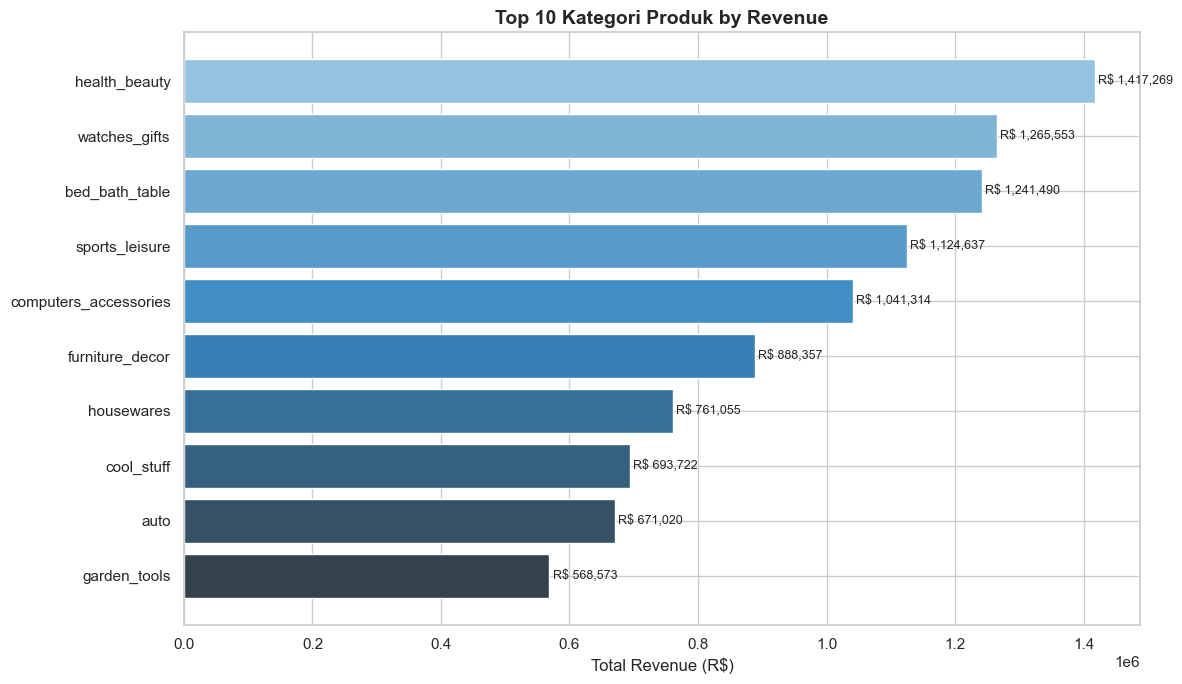

In [6]:
top_cat = ( 
    df_delivered 
    .groupby('product_category')['total_item_value'] 
    .sum() 
    .nlargest(10) 
    .reset_index() 
    .rename(columns={'total_item_value': 'revenue'}) 
) 
  
fig, ax = plt.subplots(figsize=(12, 7)) 
bars = ax.barh(top_cat['product_category'], top_cat['revenue'], 
               color=sns.color_palette('Blues_d', 10)) 
  
# Tambah label angka di tiap bar 
for bar, val in zip(bars, top_cat['revenue']): 
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2, 
            f'R$ {val:,.0f}', va='center', fontsize=9) 
  
ax.set_xlabel('Total Revenue (R$)', fontsize=12) 
ax.set_title('Top 10 Kategori Produk by Revenue', fontsize=14, fontweight='bold') 
ax.invert_yaxis() 
plt.tight_layout() 
plt.savefig('../output/figures/02_top_categories.png', dpi=150) 
plt.show() 

 Delivery Performance 

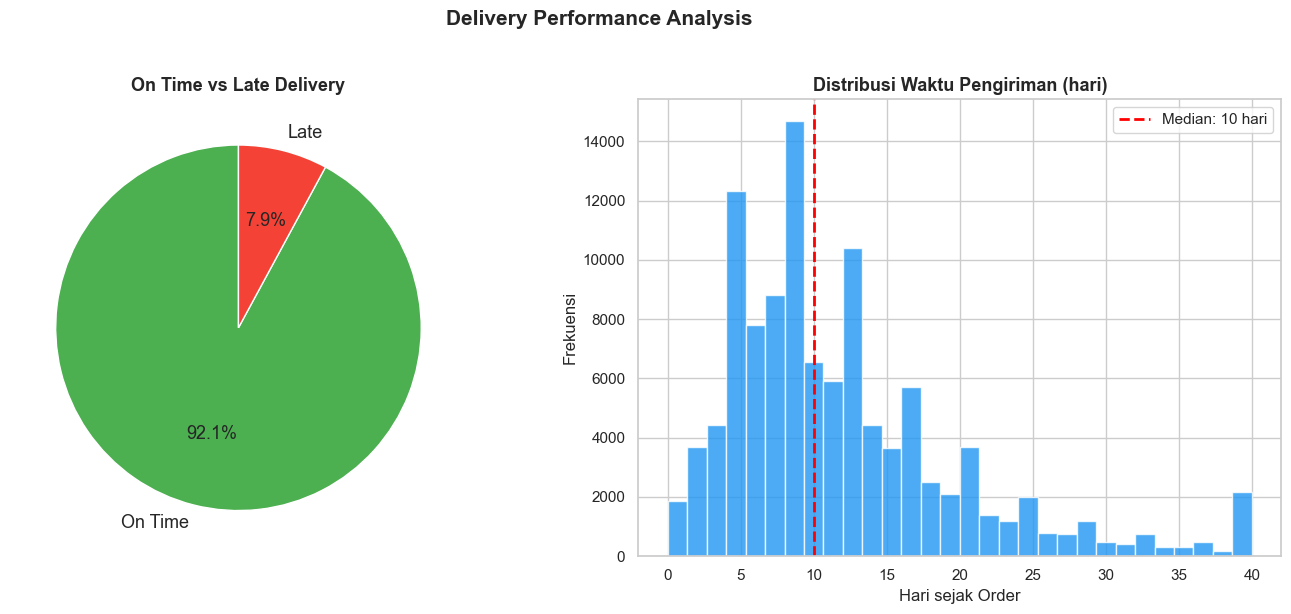

In [ ]:
delivery_df = df[df['delivery_status'].isin(['Late', 'On Time'])] \
    .dropna(subset=['delivery_days'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - On Time vs Late
status_count = delivery_df['delivery_status'].value_counts()

colors = ['#4CAF50', '#F44336']

axes[0].pie(status_count,labels=status_count.index,autopct='%1.1f%%',colors=colors,startangle=90,textprops={'fontsize': 13})

axes[0].set_title('On Time vs Late Delivery',fontsize=13,fontweight='bold')

# Histogram - distribusi delivery days
axes[1].hist(delivery_df['delivery_days'].clip(0, 40),bins=30,color='#2196F3',edgecolor='white',alpha=0.8)

# Median line
axes[1].axvline(delivery_df['delivery_days'].median(),color='red',linestyle='--',linewidth=2,
label=f'Median: {delivery_df["delivery_days"].median():.0f} hari')

axes[1].set_xlabel('Hari sejak Order')
axes[1].set_ylabel('Frekuensi')

axes[1].set_title('Distribusi Waktu Pengiriman (hari)',fontsize=13,fontweight='bold')

axes[1].legend()

plt.suptitle('Delivery Performance Analysis',fontsize=15,fontweight='bold',y=1.02)

plt.tight_layout()

plt.savefig('../output/figures/03_delivery_performance.png', dpi=150, bbox_inches='tight')

plt.show()

Review Score & Korelasi Delivery

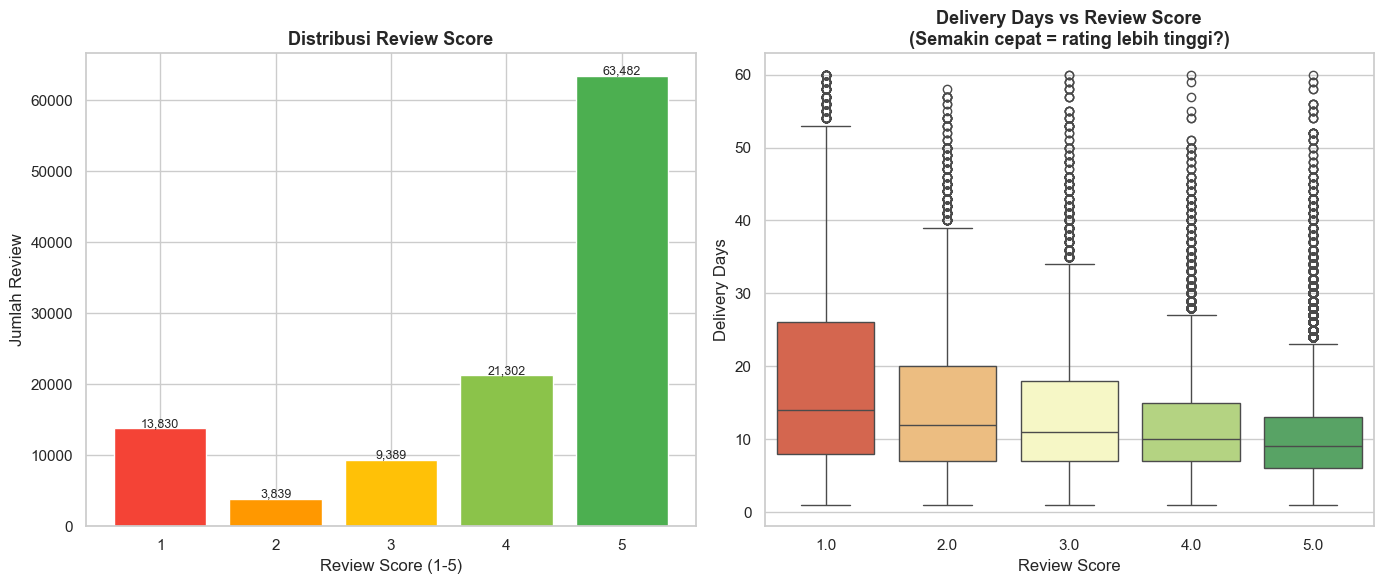

Pearson Correlation (delivery_days vs review_score): -0.3140
Interpretasi: Korelasi negatif → semakin lama delivery, semakin rendah review score


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
  
# Bar chart - Review score distribution 
review_dist = df['review_score'].value_counts().sort_index() 
colors_review = ['#F44336','#FF9800','#FFC107','#8BC34A','#4CAF50'] 
bars = axes[0].bar(review_dist.index, review_dist.values, color=colors_review) 
for bar, val in zip(bars, review_dist.values): 
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, 
                 f'{val:,}', ha='center', fontsize=9) 
axes[0].set_xlabel('Review Score (1-5)') 
axes[0].set_ylabel('Jumlah Review') 
axes[0].set_title('Distribusi Review Score', fontsize=13, fontweight='bold') 
axes[0].set_xticks([1,2,3,4,5]) 
  
# Boxplot - delivery days per review score 
corr_df = df.dropna(subset=['review_score','delivery_days']) 
corr_df = corr_df[corr_df['delivery_days'].between(1,60)] 
sns.boxplot(x='review_score', y='delivery_days', 
            data=corr_df, palette='RdYlGn', ax=axes[1]) 
axes[1].set_xlabel('Review Score') 
axes[1].set_ylabel('Delivery Days') 
axes[1].set_title('Delivery Days vs Review Score\n(Semakin cepat = rating lebih tinggi?)', 
                   fontsize=13, fontweight='bold') 
  
plt.tight_layout() 
plt.savefig('../output/figures/04_review_delivery.png', dpi=150) 
plt.show() 
  
# Korelasi Pearson 
correlation = corr_df['delivery_days'].corr(corr_df['review_score']) 
print(f'Pearson Correlation (delivery_days vs review_score): {correlation:.4f}') 
print('Interpretasi: Korelasi negatif → semakin lama delivery, semakin rendah review score') 

 Payment Methods

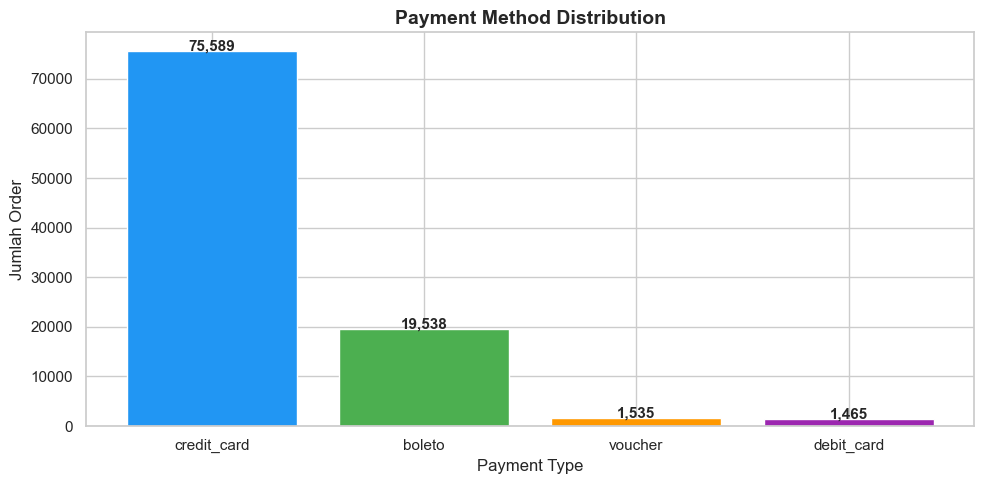

payment_type  total_orders  avg_value  avg_installments
 credit_card         75589 179.199851          3.634014
      boleto         19538 176.810734          1.000000
     voucher          1535  90.713161          1.000000
  debit_card          1465 149.113051          1.000000


In [12]:
payment = ( 
    df.groupby('payment_type') 
    .agg( 
        total_orders=('order_id', 'nunique'), 
        avg_value=('payment_value', 'mean'), 
        avg_installments=('installments', 'mean') 
    ) 
    .reset_index() 
    .sort_values('total_orders', ascending=False) 
) 
  
fig, ax = plt.subplots(figsize=(10, 5)) 
bars = ax.bar(payment['payment_type'], payment['total_orders'], 
              color=['#2196F3','#4CAF50','#FF9800','#9C27B0']) 
for bar, val in zip(bars, payment['total_orders']): 
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, 
            f'{val:,}', ha='center', fontsize=11, fontweight='bold') 
ax.set_xlabel('Payment Type') 
ax.set_ylabel('Jumlah Order') 
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold') 
plt.tight_layout() 
plt.savefig('../output/figures/05_payment_methods.png', dpi=150) 
plt.show() 
  
print(payment[['payment_type','total_orders','avg_value','avg_installments']].to_string(index=False)) 

 Export Dashboard

In [13]:
os.makedirs('../data/processed', exist_ok=True) 
  
# Export 1: Main dataset untuk dashboard 
df_export = df[df['order_status'] == 'delivered'].copy() 
df_export.to_csv('../data/processed/olist_clean_dashboard.csv', index=False) 
print(f'Exported main dataset: {len(df_export):,} rows') 
  
# Export 2: Monthly summary 
monthly.to_csv('../data/processed/monthly_summary.csv', index=False) 
  
# Export 3: Category summary 
top_cat.to_csv('../data/processed/category_revenue.csv', index=False) 
  
# Export 4: State summary 
state_summary = ( 
    df_delivered.groupby('customer_state') 
    .agg( 
        total_orders=('order_id','nunique'), 
        total_revenue=('total_item_value','sum'), 
        avg_review=('review_score','mean') 
    ) 
    .round(2) 
    .reset_index() 
) 
state_summary.to_csv('../data/processed/state_summary.csv', index=False) 
  
print('Semua file berhasil di-export ke data/processed/') 
print() 
print('Files:') 
for f in os.listdir('../data/processed'): 
    size = os.path.getsize(f'../data/processed/{f}') / 1024 
    print(f'  {f:45} {size:>8.1f} KB') 

Exported main dataset: 110,840 rows
Semua file berhasil di-export ke data/processed/

Files:
  category_revenue.csv                               0.3 KB
  monthly_summary.csv                                0.5 KB
  olist_clean_dashboard.csv                      37643.4 KB
  state_summary.csv                                  0.7 KB
